In [48]:
# import
import pandas as pd
import requests
from IPython.display import display
from datetime import datetime
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [49]:
# ETL(Extract, Transform, Load) Block:
def get_flight_data():
    # API - מאגר טיסות - EXTRACT
   
    # מזהה משאב(מגיע מהאתר)
    resource_id = "e83f763b-b7d7-479e-b172-ae981ddc6de5"

    url = f"https://data.gov.il/api/3/action/datastore_search?resource_id={resource_id}"

    # send requests to website and get response(code)
    response = requests.get(url)
    
    if response.status_code != 200:
        print(f"There is a problem: {response.status_code}")
        return None
    
    # parsing  the data we got
    data = response.json()
    
    # convert to DataFrame
    records = data['result']['records']
    df_flights = pd.DataFrame(records)
    
    #TRANSFORM

    # Rename columns to meaningful names
    df_flights = df_flights.rename(columns={
        '_id': 'id',
        'CHOPER': 'airline_code',
        'CHOPERD': 'airline_name',
        'CHFLTN': 'flight_number',
        'CHAORD': 'direction',
        'CHSTOL': 'scheduled_time',
        'CHPTOL': 'actual_time',
        'CHLOC1': 'airport_code',
        'CHLOC1D': 'airport_name',
        'CHLOC1TH': 'city_hebrew',
        'CHLOC1T': 'city_english',
        'CHLOC1CH': 'country_hebrew',
        'CHLOCCT': 'country_english',
        'CHTERM': 'terminal',
        'CHCINT': 'checkin_counters',
        'CHCKZN': 'checkin_zone',
        'CHRMINE': 'flight_status',
        'CHRMINH': 'flight_status_hebrew'
    }, errors='ignore')

    df_flights['terminal'] = pd.to_numeric(df_flights['terminal'], errors='coerce').astype('Int8')
    df_flights['flight_number'] = df_flights['flight_number'].astype(str)
    df_flights['scheduled_time'] = pd.to_datetime(df_flights['scheduled_time'])
    df_flights['actual_time'] = pd.to_datetime(df_flights['actual_time'])
    df_flights['terminal'] = pd.to_numeric(df_flights['terminal'], errors='coerce').astype('Int8')

    # missing values:
    # flights that are landing they are arrivel = mean no need to checkin so fill the empty to 'N/A'
    df_flights.loc[df_flights['direction'] == 'A', ['checkin_counters', 'checkin_zone']] = 'N/A'

    # flights that are leaving they are departure = means they do need to do check in so, if there is empty for any reason fill it as 'Missing'
    mask_missing_departures = (df_flights['direction'] == 'D') & (df_flights['checkin_counters'].isna())
    df_flights.loc[mask_missing_departures, ['checkin_counters', 'checkin_zone']] = 'Missing'
    #return to us the df - LOAD
    return df_flights


In [50]:
# update data
df_flights = get_flight_data()

# quick check for missing and duplicates rows:
# print(f"For df_flights there is: {df_flights.duplicated().sum()} duplicates rows")
# print(f"For df_flights there is: {df_flights.isna().sum()} missing values")


### EDA - Exploratory Data Analysis

In [51]:
# display the table
display(df_flights.head())

# look at the data in static way
df_flights.describe()

,id,airline_code,flight_number,airline_name,scheduled_time,actual_time,direction,airport_code,airport_name,city_hebrew,city_english,country_hebrew,country_english,terminal,checkin_counters,checkin_zone,flight_status,flight_status_hebrew
0,1,LO,155,LOT POLISH AIRLINES,2026-06-20 15:20:00,2026-06-20 15:16:00,A,WAW,WARSAW,ורשה,WARSAW,פולין,POLAND,3,N/A,N/A,LANDED,נחתה
1,2,LY,9252,EL AL ISRAEL AIRLINES,2026-06-20 15:20:00,2026-06-20 15:16:00,A,WAW,WARSAW,ורשה,WARSAW,פולין,POLAND,3,N/A,N/A,LANDED,נחתה
2,3,IZ,213,ARKIA ISRAELI AIRLINES,2026-06-20 14:00:00,2026-06-20 15:18:00,D,ATH,ATHENS,אתונה,ATHENS,יוון,GREECE,3,28-33,A,DEPARTED,המריאה
3,4,IZ,424,ARKIA ISRAELI AIRLINES,2026-06-20 15:40:00,2026-06-20 15:24:00,A,VIE,VIENNA,וינה,VIENNA,אוסטריה,AUSTRIA,3,N/A,N/A,LANDED,נחתה
4,5,EY,608,ETIHAD AIRWAYS,2026-06-20 15:15:00,2026-06-20 15:26:00,D,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,56-65,C,DEPARTED,המריאה


,id,scheduled_time,actual_time,terminal
count,2447.000000,2447,2447,2447.0
mean,1224.000000,2026-06-22 17:23:26.089088768,2026-06-22 17:30:18.806702336,3.0
min,1.000000,2026-06-20 14:00:00,2026-06-20 15:16:00,3.0
25%,612.500000,2026-06-21 18:00:00,2026-06-21 18:17:00,3.0
50%,1224.000000,2026-06-22 16:25:00,2026-06-22 16:25:00,3.0
75%,1835.500000,2026-06-23 16:00:00,2026-06-23 16:00:00,3.0
max,2447.000000,2026-06-24 15:15:00,2026-06-24 15:15:00,3.0
std,706.532377,NaN,NaN,0.0


In [52]:
# create delay column:
df_flights['delay'] = (df_flights['actual_time'] - df_flights['scheduled_time']).dt.total_seconds()/60

display(df_flights.head())

,id,airline_code,flight_number,airline_name,scheduled_time,actual_time,direction,airport_code,airport_name,city_hebrew,city_english,country_hebrew,country_english,terminal,checkin_counters,checkin_zone,flight_status,flight_status_hebrew,delay
0,1,LO,155,LOT POLISH AIRLINES,2026-06-20 15:20:00,2026-06-20 15:16:00,A,WAW,WARSAW,ורשה,WARSAW,פולין,POLAND,3,N/A,N/A,LANDED,נחתה,-4.0
1,2,LY,9252,EL AL ISRAEL AIRLINES,2026-06-20 15:20:00,2026-06-20 15:16:00,A,WAW,WARSAW,ורשה,WARSAW,פולין,POLAND,3,N/A,N/A,LANDED,נחתה,-4.0
2,3,IZ,213,ARKIA ISRAELI AIRLINES,2026-06-20 14:00:00,2026-06-20 15:18:00,D,ATH,ATHENS,אתונה,ATHENS,יוון,GREECE,3,28-33,A,DEPARTED,המריאה,78.0
3,4,IZ,424,ARKIA ISRAELI AIRLINES,2026-06-20 15:40:00,2026-06-20 15:24:00,A,VIE,VIENNA,וינה,VIENNA,אוסטריה,AUSTRIA,3,N/A,N/A,LANDED,נחתה,-16.0
4,5,EY,608,ETIHAD AIRWAYS,2026-06-20 15:15:00,2026-06-20 15:26:00,D,AUH,ABU DHABI,אבו דאבי,ABU DHABI,איחוד האמירויות הערב,UNITED ARAB EMIRATES,3,56-65,C,DEPARTED,המריאה,11.0


### The Goal of Project:
#### 1.How many flight from start of the day till now?
#### 2. 

In [53]:
# 1.How many flight from start of the day till now?
# to get the date of today
now = datetime.now()
today = now.date()

today_flight = df_flights[
    (df_flights['actual_time'].dt.date == today) &
    (df_flights['actual_time'] <= now)
]
print(f"Today is {today} was {len(today_flight)} flights")

Today is 2026-06-21 was 381 flights


In [54]:
# 2. Which flight company is popular
flight_company = today_flight['airline_name'].value_counts()
# print(flight_company.head(5))

# bar chart to display the popular flight company today:
# first convert flight_company into df for easy create plot:
plot_flight_company = flight_company.reset_index()


# top 5 airline - head(5)
top_airline = plot_flight_company.sort_values(by='count', ascending=False).head(5)

# columns names
top_airline.columns = ['airline_name', 'count']

#color palette:
my_custom_palette = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'] 

# bulid the chart:
fig = px.bar(
    top_airline, x='count', y='airline_name',orientation='h',color='airline_name',color_discrete_sequence=my_custom_palette,
    title="Number of flights by airline:", labels={'count':'Number of flights','airline_name':'Flight Company'})

fig.show()


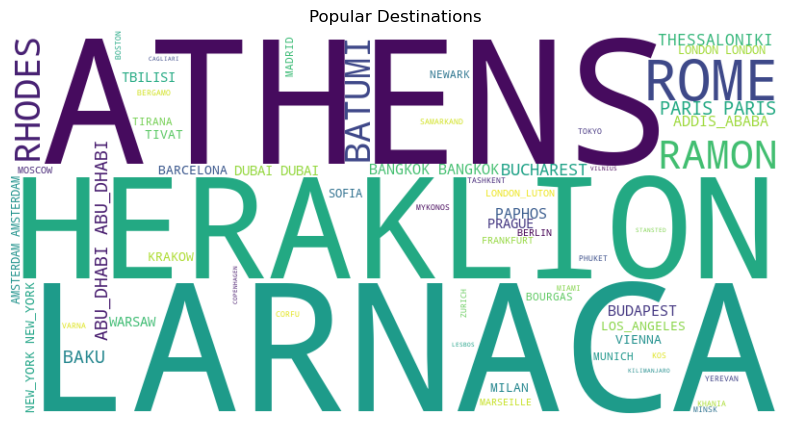

In [55]:
# 3. Which destinations are popular - Most Popular Destinations:
city_list = today_flight['city_english'].str.replace(' ', '_').dropna()
destinations_names = " ".join(city_list)

# wordCloud chart:
wordcloud = WordCloud(
    width=800 , height=400, background_color='white', colormap='viridis',random_state=42
).generate(destinations_names)

# display wordCloud chart:
plt.figure(figsize=(15,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Destinations")
plt.show()

In [ ]:
# 4. How many 
israeli_airline = ['EL AL ISRAEL AIRLINES', 'ARKIA ISRAELI AIRLINES', 'ISRAIR AIRLINES']

